# 02 · Machine Learning con Scikit-Learn

> 🇬🇧 English version: [`02_scikit_learn_en.ipynb`](02_scikit_learn_en.ipynb)

Scikit-learn sigue siempre el mismo patrón: `modelo.fit(X, y)` → `modelo.predict(X_nuevo)`.
En este notebook construimos un flujo **completo y correcto**:

1. Separar *train* / *test* **antes** de tocar los datos.
2. Preprocesar con `ColumnTransformer` + `Pipeline` (evita fuga de datos / *data leakage*).
3. Comparar modelos con validación cruzada.
4. Ajustar hiperparámetros con `GridSearchCV`.
5. Evaluar una sola vez en *test* e interpretar.
6. Bonus: clasificación.

Los datos se cargan con **Polars**, que scikit-learn acepta directamente.

In [1]:
# Librerias a usar
#=====================================================
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import sklearn
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.model_selection import GridSearchCV, KFold, cross_validate, train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

print("scikit-learn", sklearn.__version__)
SEMILLA = 42

scikit-learn 1.9.1


## 1. Cargar datos y separar train / test

In [2]:
df = pl.read_csv("datos/casas.csv")

X = df.drop("id", "precio")
y = df["precio"].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEMILLA)
print(X_train.shape, X_test.shape)
X_train.head()

(1600, 6) (400, 6)


barrio,metros,habitaciones,antiguedad,distancia_centro_km,tiene_cochera
str,f64,i64,f64,f64,str
"""Sur""",87.4,1,null,24.08,"""no"""
"""Periferia""",45.0,1,32.0,9.18,"""si"""
"""Norte""",95.0,3,35.0,4.48,"""no"""
"""Norte""",92.0,2,1.0,4.78,"""no"""
"""Sur""",35.0,1,2.0,5.16,"""no"""


## 2. Preprocesamiento dentro de un Pipeline

- **Numéricas**: imputar faltantes con la mediana → estandarizar (media 0, desviación 1).
- **Categóricas**: one-hot encoding.

Al meter todo en un `Pipeline`, la mediana y la escala se calculan **solo con los datos de entrenamiento**
de cada *fold*: así la evaluación es honesta.

In [3]:
numericas = ["metros", "habitaciones", "antiguedad", "distancia_centro_km"]
categoricas = ["barrio", "tiene_cochera"]

preprocesador = ColumnTransformer([
    ("num", Pipeline([
        ("imputar", SimpleImputer(strategy="median")),
        ("escalar", StandardScaler()),
    ]), numericas),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categoricas),
])

# Ver qué produce (lo devolvemos como Polars para leerlo cómodo)
preprocesador.set_output(transform="polars")
preprocesador.fit_transform(X_train).head()

num__metros,num__habitaciones,num__antiguedad,num__distancia_centro_km,cat__barrio_Centro,cat__barrio_Norte,cat__barrio_Periferia,cat__barrio_Sur,cat__tiene_cochera_no,cat__tiene_cochera_si
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
-0.694688,-1.686346,-0.014466,1.681431,0.0,0.0,0.0,1.0,1.0,0.0
-1.943254,-1.686346,0.162669,-0.255379,0.0,0.0,1.0,0.0,0.0,1.0
-0.470888,-0.142338,0.339804,-0.866319,0.0,1.0,0.0,0.0,1.0,0.0
-0.55923,-0.914342,-1.667726,-0.827322,0.0,1.0,0.0,0.0,1.0,0.0
-2.237727,-1.686346,-1.608681,-0.777927,0.0,0.0,0.0,1.0,1.0,0.0


## 3. Comparar modelos con validación cruzada (5 folds)

In [4]:
modelos = {
    "Regresión lineal": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "KNN (k=5)": KNeighborsRegressor(n_neighbors=5),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=SEMILLA, n_jobs=-1),
    "Gradient Boosting": HistGradientBoostingRegressor(random_state=SEMILLA),
}

cv = KFold(n_splits=5, shuffle=True, random_state=SEMILLA)
resultados = []
for nombre, modelo in modelos.items():
    pipe = Pipeline([("prep", preprocesador), ("modelo", modelo)])
    s = cross_validate(pipe, X_train, y_train, cv=cv,
                       scoring={"rmse": "neg_root_mean_squared_error", "r2": "r2"})
    resultados.append({"modelo": nombre,
                       "RMSE": -s["test_rmse"].mean(),
                       "RMSE_std": s["test_rmse"].std(),
                       "R2": s["test_r2"].mean()})

pl.DataFrame(resultados).sort("RMSE")

modelo,RMSE,RMSE_std,R2
str,f64,f64,f64
"""Gradient Boosting""",24444.234119,1426.716486,0.94533
"""Random Forest""",26889.914201,1804.69204,0.933808
"""KNN (k=5)""",29337.227394,1697.720782,0.921157
"""Regresión lineal""",33125.502468,1180.957548,0.899617
"""Ridge""",33125.990239,1166.73176,0.899617


## 4. Ajuste de hiperparámetros

`GridSearchCV` prueba todas las combinaciones con validación cruzada.
Los parámetros de un paso del pipeline se nombran `paso__parametro`.

In [5]:
pipe_gb = Pipeline([("prep", preprocesador),
                    ("modelo", HistGradientBoostingRegressor(random_state=SEMILLA))])

grid = GridSearchCV(
    pipe_gb,
    param_grid={
        "modelo__learning_rate": [0.05, 0.1],
        "modelo__max_depth": [None, 4, 8],
        "modelo__max_iter": [200, 400],
    },
    cv=cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
)
grid.fit(X_train, y_train)
print("Mejores parámetros:", grid.best_params_)
print(f"RMSE CV: {-grid.best_score_:,.0f}")

Mejores parámetros: {'modelo__learning_rate': 0.05, 'modelo__max_depth': 4, 'modelo__max_iter': 400}
RMSE CV: 23,553


## 5. Evaluación final en test (solo una vez)

MAE : 15,398
RMSE: 20,082
R²  : 0.960


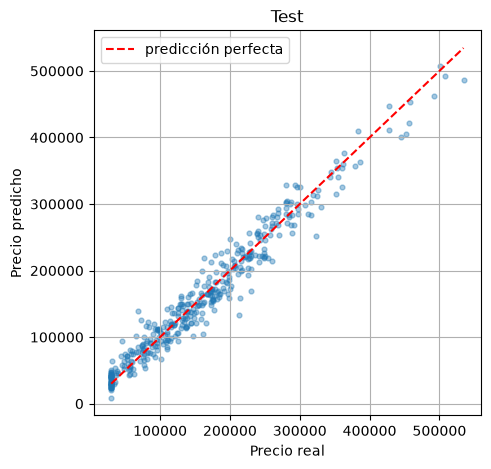

In [6]:
mejor = grid.best_estimator_
pred = mejor.predict(X_test)

print(f"MAE : {mean_absolute_error(y_test, pred):,.0f}")
print(f"RMSE: {root_mean_squared_error(y_test, pred):,.0f}")
print(f"R²  : {r2_score(y_test, pred):.3f}")

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(y_test, pred, alpha=0.4, s=12)
lim = [y_test.min(), y_test.max()]
ax.plot(lim, lim, "r--", label="predicción perfecta")
ax.set(xlabel="Precio real", ylabel="Precio predicho", title="Test")
ax.legend(); ax.grid(True)
plt.show()

### ¿Qué variables importan?
*Permutation importance*: cuánto empeora el modelo si barajamos una columna.

In [7]:
# permutation_importance aún no acepta Polars: le pasamos Pandas
imp = permutation_importance(mejor, X_test.to_pandas(), y_test, n_repeats=10, random_state=SEMILLA,
                             scoring="neg_root_mean_squared_error")
pl.DataFrame({"variable": X_test.columns, "importancia": imp.importances_mean}).sort("importancia", descending=True)

variable,importancia
str,f64
"""metros""",68849.895504
"""antiguedad""",44329.700235
"""barrio""",35372.642645
"""distancia_centro_km""",28458.852881
"""habitaciones""",8927.604566
"""tiene_cochera""",3376.877005


### Guardar y cargar el modelo

In [8]:
import joblib

joblib.dump(mejor, "modelo_casas.joblib")
cargado = joblib.load("modelo_casas.joblib")

casa_nueva = pl.DataFrame({
    "barrio": ["Norte"], "metros": [120.0], "habitaciones": [3], "antiguedad": [10.0],
    "distancia_centro_km": [6.5], "tiene_cochera": ["si"],
})
print(f"Precio estimado: {cargado.predict(casa_nueva)[0]:,.0f}")

Precio estimado: 256,914


## 6. Bonus: clasificación

Mismo patrón, otra tarea: predecir si una casa es **cara** (precio por encima de la mediana).
Cambian el modelo y las métricas.

              precision    recall  f1-score   support

      barata       0.94      0.94      0.94       190
        cara       0.94      0.94      0.94       210

    accuracy                           0.94       400
   macro avg       0.94      0.94      0.94       400
weighted avg       0.94      0.94      0.94       400



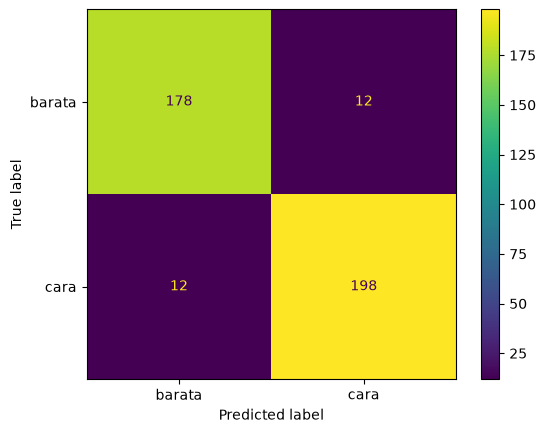

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

umbral = np.median(y_train)
yc_train, yc_test = (y_train > umbral).astype(int), (y_test > umbral).astype(int)

clf = Pipeline([("prep", preprocesador), ("modelo", LogisticRegression(max_iter=1000))])
clf.fit(X_train, yc_train)
pred_c = clf.predict(X_test)

print(classification_report(yc_test, pred_c, target_names=["barata", "cara"]))
ConfusionMatrixDisplay.from_predictions(yc_test, pred_c, display_labels=["barata", "cara"])
plt.show()

## Resumen
- `train_test_split` primero; el *test* no se toca hasta el final.
- `Pipeline` + `ColumnTransformer` = preprocesamiento sin fugas y reproducible.
- `cross_validate` para comparar, `GridSearchCV` para ajustar.
- Métricas: regresión (MAE, RMSE, R²), clasificación (precision, recall, F1, matriz de confusión).

## ✏️ Ejercicios
1. Añade una variable `metros_por_habitacion` (con Polars antes del split) y mira si mejora el RMSE.
2. Prueba `RandomizedSearchCV` sobre el `RandomForestRegressor` (`n_estimators`, `max_depth`, `min_samples_leaf`).
3. En la clasificación, prueba `RandomForestClassifier` y compara con `roc_auc_score`.
4. Compara con tu notebook de regresión lineal y KNN en la raíz del repo: ¿por qué aquí KNN necesita escalar?